In [1]:
import pandas as pd
import sqlite3

# Create (or connect to) a local SQLite database file in Colab
conn = sqlite3.connect("covid_usa.db")
conn

In [2]:
import pandas as pd

base_url = "https://raw.githubusercontent.com/MChanda17/covid-county-sql-analysis/main/data/"

counties = pd.read_csv(base_url + "us_counties_covid19_daily.csv")
states   = pd.read_csv(base_url + "us_states_covid19_daily.csv")
national = pd.read_csv(base_url + "us_covid19_daily.csv")

# Quick sanity check
counties.head(), states.head(), national.head()

(         date     county       state     fips  cases  deaths
 0  2020-01-21  Snohomish  Washington  53061.0      1     0.0
 1  2020-01-22  Snohomish  Washington  53061.0      1     0.0
 2  2020-01-23  Snohomish  Washington  53061.0      1     0.0
 3  2020-01-24       Cook    Illinois  17031.0      1     0.0
 4  2020-01-24  Snohomish  Washington  53061.0      1     0.0,
        date state  positive  probableCases   negative  pending  \
 0  20201206    AK   35720.0            NaN  1042056.0      NaN   
 1  20201206    AL  269877.0        45962.0  1421126.0      NaN   
 2  20201206    AR  170924.0        22753.0  1614979.0      NaN   
 3  20201206    AS       0.0            NaN     2140.0      NaN   
 4  20201206    AZ  364276.0        12590.0  2018813.0      NaN   
 
   totalTestResultsSource  totalTestResults  hospitalizedCurrently  \
 0        totalTestsViral         1077776.0                  164.0   
 1  totalTestsPeopleViral         1645041.0                 1927.0   
 2        tot

In [14]:
counties.to_sql("us_counties_daily", conn, if_exists="replace", index=False)
states.to_sql("us_states_daily", conn, if_exists="replace", index=False)
national.to_sql("us_national_daily", conn, if_exists="replace", index=False)

320

In [15]:
!pip install ipython-sql

In [17]:
import sqlite3
import pandas as pd

# connect to the same SQLite file
conn = sqlite3.connect("covid_usa.db")

In [18]:
query = """
SELECT *
FROM us_counties_daily
LIMIT 5;
"""

counties_head = pd.read_sql_query(query, conn)
counties_head

,date,county,state,fips,cases,deaths
0,2020-01-21,Snohomish,Washington,53061.0,1,0.0
1,2020-01-22,Snohomish,Washington,53061.0,1,0.0
2,2020-01-23,Snohomish,Washington,53061.0,1,0.0
3,2020-01-24,Cook,Illinois,17031.0,1,0.0
4,2020-01-24,Snohomish,Washington,53061.0,1,0.0


In [19]:
schema_counties = pd.read_sql_query(
    "PRAGMA table_info(us_counties_daily);",
    conn
)
schema_counties

,cid,name,type,notnull,dflt_value,pk
0,0,date,TEXT,0,None,0
1,1,county,TEXT,0,None,0
2,2,state,TEXT,0,None,0
3,3,fips,REAL,0,None,0
4,4,cases,INTEGER,0,None,0
5,5,deaths,REAL,0,None,0


In [20]:
schema_states = pd.read_sql_query(
    "PRAGMA table_info(us_states_daily);",
    conn
)
schema_states.head()

,cid,name,type,notnull,dflt_value,pk
0,0,date,INTEGER,0,None,0
1,1,state,TEXT,0,None,0
2,2,positive,REAL,0,None,0
3,3,probableCases,REAL,0,None,0
4,4,negative,REAL,0,None,0


# Q1. Which counties have the highest cumulative COVID-19 case counts on the latest date in the dataset?

In [21]:
q_top_counties = """
SELECT
    date,
    county,
    state,
    cases,
    deaths
FROM us_counties_daily
WHERE date = (SELECT MAX(date) FROM us_counties_daily)
ORDER BY cases DESC
LIMIT 10;
"""

top_counties = pd.read_sql_query(q_top_counties, conn)
top_counties

,date,county,state,cases,deaths
0,2020-12-05,Los Angeles,California,439538,7886.0
1,2020-12-05,New York City,New York,332633,24346.0
2,2020-12-05,Cook,Illinois,325813,6922.0
3,2020-12-05,Miami-Dade,Florida,241050,3896.0
4,2020-12-05,Maricopa,Arizona,228051,4146.0
5,2020-12-05,Harris,Texas,196658,3060.0
6,2020-12-05,Dallas,Texas,146320,1620.0
7,2020-12-05,Clark,Nevada,126066,1850.0
8,2020-12-05,Broward,Florida,112729,1694.0
9,2020-12-05,Tarrant,Texas,108480,1094.0


# Q2. On the latest date in the dataset, which states have the highest total number of cases and deaths?

In [22]:
q_state_totals = """
SELECT
    date,
    state,
    SUM(cases) AS total_cases,
    SUM(deaths) AS total_deaths
FROM us_counties_daily
WHERE date = (SELECT MAX(date) FROM us_counties_daily)
GROUP BY date, state
ORDER BY total_cases DESC
LIMIT 10;
"""

state_totals = pd.read_sql_query(q_state_totals, conn)
state_totals

,date,state,total_cases,total_deaths
0,2020-12-05,California,1343145,19876.0
1,2020-12-05,Texas,1333809,23111.0
2,2020-12-05,Florida,1049630,19083.0
3,2020-12-05,Illinois,781441,14028.0
4,2020-12-05,New York,700902,34488.0
5,2020-12-05,Georgia,481126,9506.0
6,2020-12-05,Ohio,467432,6947.0
7,2020-12-05,Wisconsin,437918,3938.0
8,2020-12-05,Michigan,425776,10313.0
9,2020-12-05,Pennsylvania,416073,11331.0


# Question 3 – What does the national trend of COVID-19 cases and deaths look like over time?

In [23]:
q_us_trend = """
SELECT
    date,
    SUM(cases) AS total_cases,
    SUM(deaths) AS total_deaths
FROM us_counties_daily
GROUP BY date
ORDER BY date;
"""

us_trend = pd.read_sql_query(q_us_trend, conn)
us_trend.head()

,date,total_cases,total_deaths
0,2020-01-21,1,0.0
1,2020-01-22,1,0.0
2,2020-01-23,1,0.0
3,2020-01-24,2,0.0
4,2020-01-25,3,0.0


# Q1 Visualization — Top 10 Counties by Cases (Bar Chart)

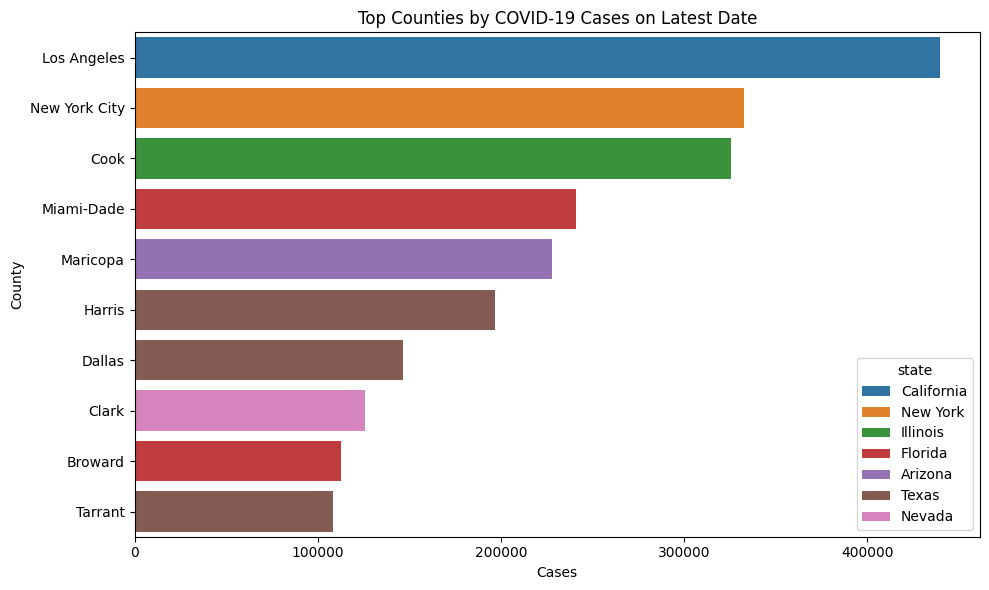

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_counties,
    x="cases",
    y="county",
    hue="state",
    dodge=False
)
plt.title("Top Counties by COVID-19 Cases on Latest Date")
plt.xlabel("Cases")
plt.ylabel("County")
plt.tight_layout()
plt.show()

# Q2 Visualization — Top 10 States by Total Cases (Bar Chart)

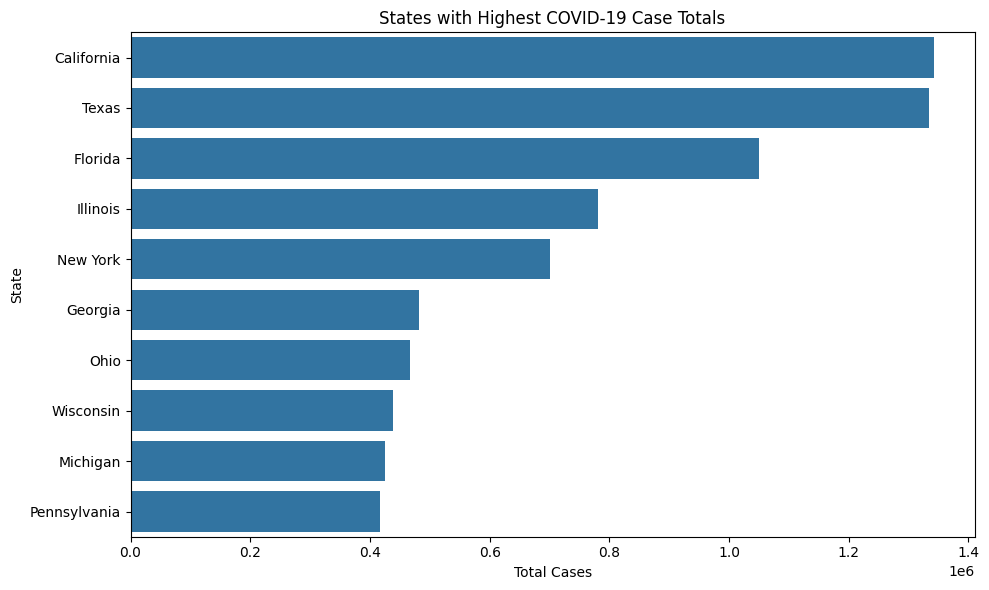

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=state_totals,
    x="total_cases",
    y="state"
)
plt.title("States with Highest COVID-19 Case Totals")
plt.xlabel("Total Cases")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# Q3 Visualization — U.S. National Trend Over Time

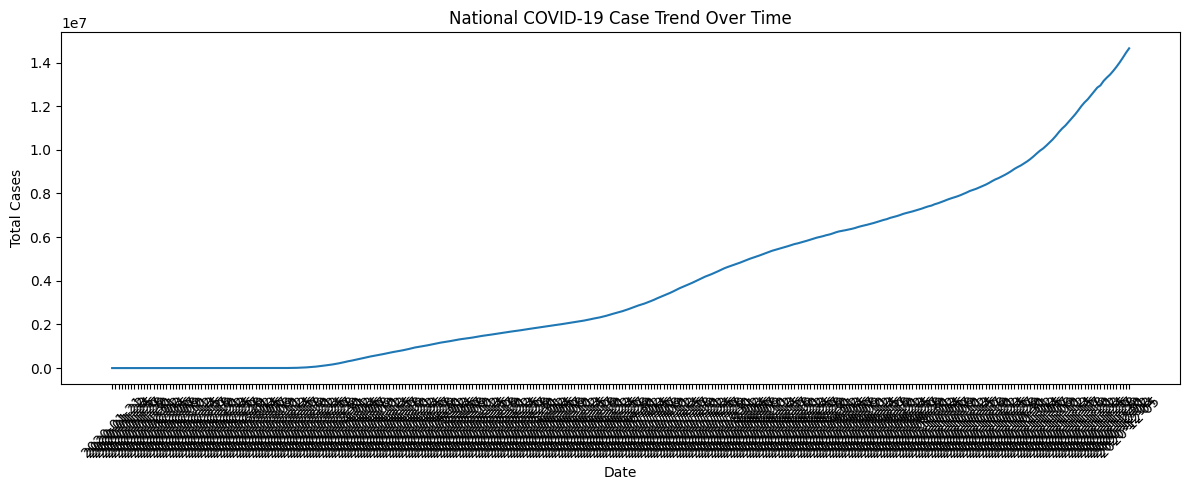

In [27]:
plt.figure(figsize=(12,5))
plt.plot(us_trend['date'], us_trend['total_cases'])
plt.title("National COVID-19 Case Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()